In [ ]:
# importation des packages
import os
import re
import openpyxl as xl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from datetime import datetime,date

# standarisation
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

from itertools import combinations
import warnings

warnings.simplefilter("ignore")

In [ ]:
# chargement des données
path = r"../data/2024-10-29 Aout 2023 a 29 jan 2025.xlsm"
df = pd.read_excel(path)

In [ ]:
# renommer
df.rename(columns={
    "st20_b_Value_pos24": "Accostage", 
    "st20_b_Value_pos20":"Emmanchement", 
    "ratio":"Ratio"
    }, inplace=True)


In [ ]:
# tracer les courbes
def showplot(x,y):
    plt.scatter(x,y)
    plt.xticks([])
    plt.ylabel(f"{y.name}")
    plt.title(f"Evolution de {y.name}")
    plt.show()

## Création de nouvelle colonne **diff** et affichages des courbes correspondants

In [ ]:
# prétraitement des données: transformation en floate
df[["Accostage","Emmanchement","Ratio"]] = df[["Accostage","Emmanchement","Ratio"]].apply(lambda x: pd.to_numeric(x, errors="coerce"))

# nouvelle colonne "diff ""
df["diff"]  = df["Accostage"] - df["Emmanchement"]


df = df[
    (df["Accostage"].notna()) & 
    (df["Emmanchement"].notna()) &
    (df["Ratio"].notna())
]

df = df[
    (df["Accostage"]!=0) & 
    (df["Emmanchement"]!=0) &
    (df["Ratio"]!=0)
 
]

In [ ]:
# déclaration des colonnes à étudier
cols = [
    "Accostage", 
    "Emmanchement",
    "Ratio",
    "diff"
]

In [ ]:
# Obtenir les nouvelles colonnes selon besoin
window_size = 50
for ele in cols:
    col_name = f"avg_{ele}"
    df[col_name] = df[ele].rolling(window=window_size, min_periods=1).mean()

for ele in cols:
    col_name = f"std_{ele}"
    df[col_name] = df[ele].rolling(window=window_size, min_periods=1).std()


In [ ]:
# changement des colonnes à étudier
cols = [
    "std_diff",
    "std_Accostage",
    "std_Ratio",
    "std_Emmanchement"
]

In [ ]:
# filtrer les colonnes selon besoin pour éviter les valeurs aberrantes
filters = {
    # "std_diff": lambda x: x < 200,
    "std_Accostage": lambda x: (x < 200),
    # "std_Ratio": lambda x:  (x < 0.9),
    # "std_Emmanchement": lambda x: (x < 200)
}

filtrages à rajouter:
    Accostage < 525

Filtres de groupes:
len(groupe)<10 => merge en un groupe et prend la premiere indice

Récupération du groupe dont std_ratio > 0.8 (la date des 50 échantillons)

Implémenter la fonction:
    Recherche des groupes en fonction de horodatage(temps)

In [ ]:
# copier le dataset
df_filtered = df.copy()

In [ ]:
df.shape  

(347608, 27)

In [ ]:
df_filtered.shape

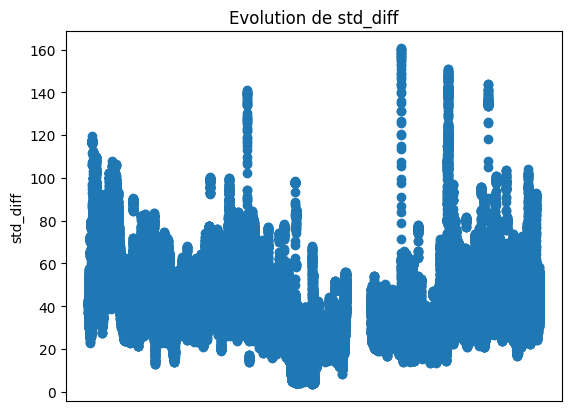

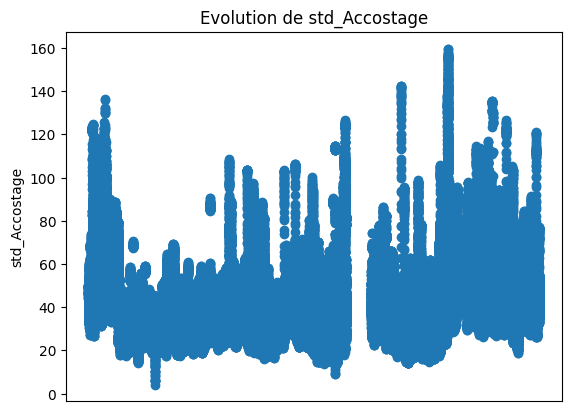

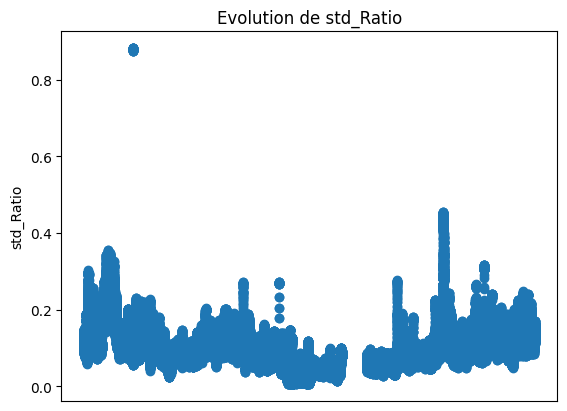

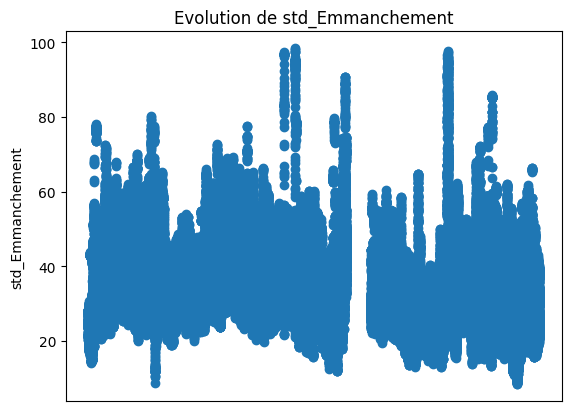

In [ ]:
# affichage des courbres selon besoin
for col in filters.keys():
    df_filtered = df_filtered[df_filtered[col].notna() & filters[col](df_filtered[col])]
for col in cols:
    showplot(df_filtered.index, df_filtered[col])

## Regroupement des échantillons en fonction d'événements (**stop_maintenance** et **stop_lot&essais**)

In [14]:
df.columns

Index(['ID', 'st10_a_HORODATAGE', 'st20_b_HORODATAGE', 'st20_b_Code_result',
       'st20_b_Code_Cible', 'st20_b_Code_planetaire', 'Accostage',
       'Emmanchement', 'Ratio', 'stop_maintenance', 'stop_lot&essais',
       'Completion Comment', 'Breakdown Comment', 'commentaire Frédéric',
       'Evénement', 'Resumé', 'Source', 'time index', 'diff', 'avg_Accostage',
       'avg_Emmanchement', 'avg_Ratio', 'avg_diff', 'std_Accostage',
       'std_Emmanchement', 'std_Ratio', 'std_diff'],
      dtype='object')

In [ ]:
# définition des groupes d'échantillons
groups_index = df[(df['stop_maintenance'].notna()) | (df['stop_lot&essais'].notna())].index

In [16]:
groups_index

Index([   564,  15602,  26668,  39444,  43470,  43637,  48589,  48905,  52772,
        67068,  82087,  88567,  95294, 106317, 115199, 115216, 115240, 125601,
       134700, 134800, 135056, 135404, 135502, 135707, 136416, 142345, 143022,
       153089, 159916, 160106, 160368, 160840, 161432, 162277, 169200, 169412,
       171794, 172850, 175088, 176651, 184058, 184720, 206441, 209572, 210353,
       210482, 256568, 256569, 256686, 258991, 267128, 294398],
      dtype='int64')

In [ ]:
# sauvegarde des échantillons dans chaque intervals de groups_index
groups_df = []

for i in range(len(groups_index) - 1):
    start, end = groups_index[i], groups_index[i + 1]
    new_df = df.loc[start:end].copy() 
    groups_df.append(new_df)

In [18]:
groups_df

[          ID                    st10_a_HORODATAGE     st20_b_HORODATAGE  \
 564     1501                 A0008652 A0032030100   27/10/2023 09:47:48   
 565     1503                 A0008648 A0032030100   27/10/2023 09:48:39   
 566     1504                 A0008643 A0032030100   27/10/2023 09:50:18   
 567     1505                 A0008645 A0032030100   27/10/2023 09:50:41   
 568     1506                 A0008641 A0032030100   27/10/2023 09:51:15   
 ...      ...                                  ...                   ...   
 15598  17850  A0022266 A0032030100 07 02 24 23 20   08/02/2024 03:45:06   
 15599  17851  A0022271 A0032030100 07 02 24 23 22   08/02/2024 03:45:55   
 15600  17852  A0022269 A0032030100 07 02 24 23 21   08/02/2024 03:46:50   
 15601  17853  A0022267 A0032030100 07 02 24 23 21   08/02/2024 03:47:41   
 15602  17854  A0022101 A0032030100 07 02 24 22 12   08/02/2024 03:48:24   
 
       st20_b_Code_result   st20_b_Code_Cible st20_b_Code_planetaire  \
 564          

TODO: le groups_index ci-dessus ne comprends pas les deux groups de début et de fin, c'est à dire que le group début dont l'index est de 0 à 563, et le group de fin dont l'index est de 294398 à 347608(l'index du dernier échantillon). Rajoutez-les dans le groups_index ci-dessus.


Faite attention également avec le nombre d'élément de groupe, par exemple le groupe avec l'index 256568 contient seulement un échantillon car le groupe prochain est avec l'index 256569, qui est juste après 256568.

## Clustering (TODO: pas encore livré)

In [ ]:
# Définition des colonnes à étudier
cluster_df = df.copy()
cluster_df = cluster_df[
    (cluster_df["Accostage"]<1200) &
    (cluster_df["Emmanchement"]<800)
    ]
data = cluster_df[['Emmanchement','Accostage']].values

In [ ]:
# critère de coude pour déterminer le K optimal
distortions = []
K = range(1,15)
for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(data)
    distortions.append(kmeanModel.inertia_)
plt.figure(figsize=(16,8))
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('SSE')
plt.title('Valeur de K optimal')
plt.show()

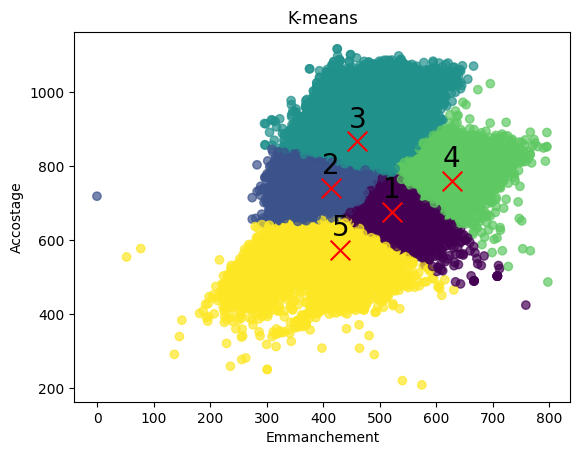

In [ ]:
# application de KMeans
n_clusters=5

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(data)

plt.scatter(data[:, 0], data[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], color='red', marker='x', s=200)

for i, (x, y) in enumerate(kmeans.cluster_centers_):
    plt.annotate(i+1, (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=20)


plt.ylabel('Accostage')
plt.xlabel('Emmanchement')
plt.title('K-means')
plt.show()
